# 📊 ARIMA Model - AirPassengers Dataset

## Objective
To implement the ARIMA model for forecasting passenger numbers and analyze trends and seasonality in time series data.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [31]:
df = pd.read_csv("AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [32]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

data = df['#Passengers']

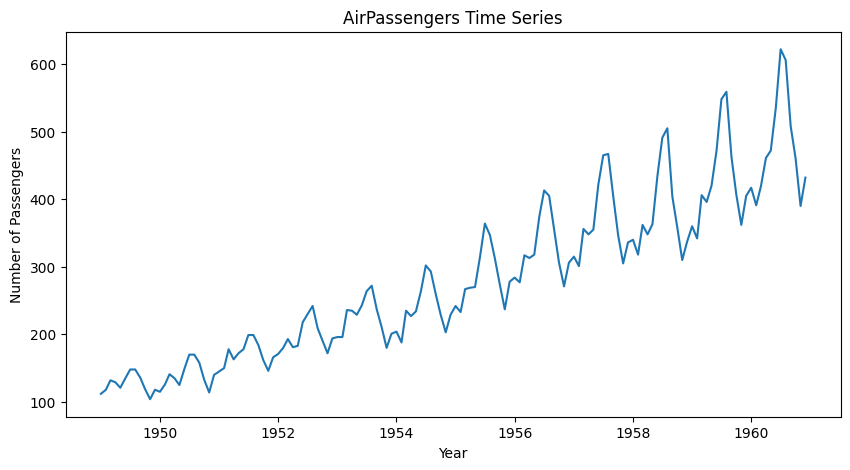

In [33]:
plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()

### 🔹 Observation
The data shows an increasing trend and clear seasonality.

In [34]:
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

In [35]:
#Using (p=2, d=1, q=2)
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

In [37]:
mse = mean_squared_error(test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 6808.397031135295


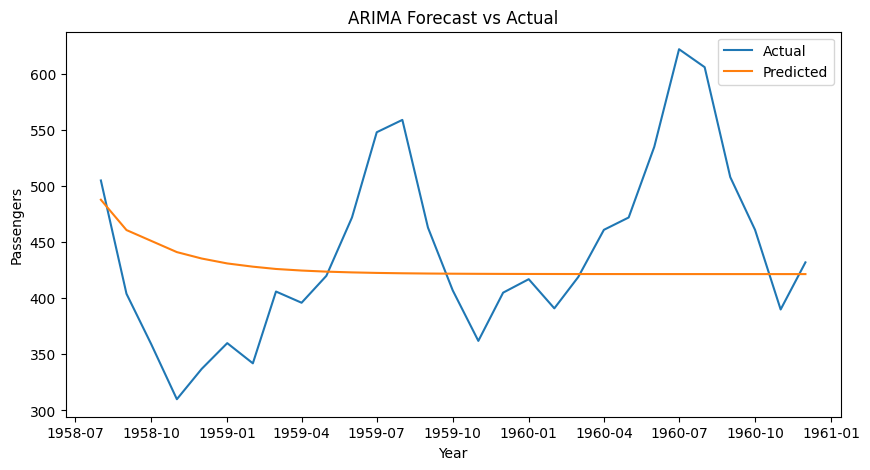

In [38]:
plt.figure(figsize=(10,5))

plt.plot(test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

### 🔹 Observations

- The dataset shows both trend and seasonality  
- ARIMA captures the overall upward trend  
- Predictions follow actual values but may slightly lag  
- Differencing (d=1) removes trend to make data stationary  

## ✅ Conclusion

ARIMA is an effective model for time series forecasting.  
It helps in modeling trend and patterns in passenger data and predicting future values.